In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms

import matplotlib.pyplot as plt

import os
from PIL import Image
import random

torch.__version__

'2.9.0+cu126'

In [ ]:
transform = transforms.ToTensor()

In [ ]:
train_data = torchvision.datasets.MNIST(root="data",
                                        train=True,
                                        transform=transform,
                                        download=True)
test_data = torchvision.datasets.MNIST(root="data",
                                       train=False,
                                       transform=transform,
                                       download=True)

In [ ]:
len(train_data), len(test_data), train_data, test_data, type(train_data), train_data.class_to_idx, train_data.classes

(60000,
 10000,
 Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor(),
 torchvision.datasets.mnist.MNIST,
 {'0 - zero': 0,
  '1 - one': 1,
  '2 - two': 2,
  '3 - three': 3,
  '4 - four': 4,
  '5 - five': 5,
  '6 - six': 6,
  '7 - seven': 7,
  '8 - eight': 8,
  '9 - nine': 9},
 ['0 - zero',
  '1 - one',
  '2 - two',
  '3 - three',
  '4 - four',
  '5 - five',
  '6 - six',
  '7 - seven',
  '8 - eight',
  '9 - nine'])

In [ ]:
exp_img_tensor, exp_img_label = train_data[0]
exp_img_tensor, exp_img_label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

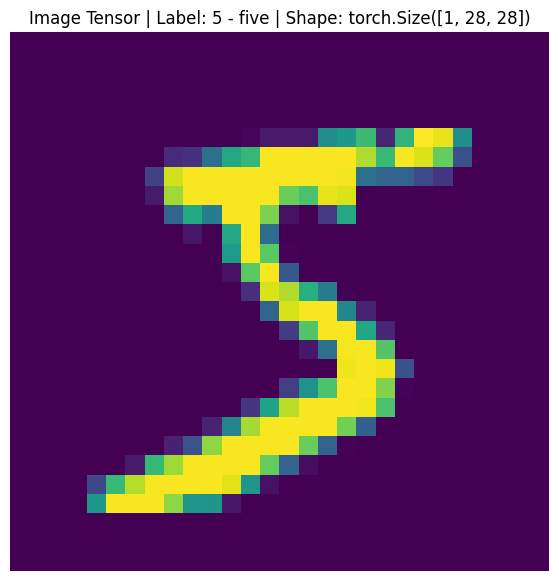

In [ ]:
plt.figure(figsize=(10, 7))
plt.imshow(exp_img_tensor.squeeze(0))
plt.title(f"Image Tensor | Label: {train_data.classes[exp_img_label]} | Shape: {exp_img_tensor.shape}")
plt.axis("off")
plt.show()

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=NUM_WORKERS,
                              shuffle=True)
test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             shuffle=False)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7b8187e9faa0>,
 <torch.utils.data.dataloader.DataLoader at 0x7b8187ecbf80>)

In [ ]:
class TinyVGGModel(nn.Module):
  def __init__(self, input_units, hidden_units, output_units):
    super().__init__()
    self.conv_block_1 = nn.Sequential(nn.Conv2d(in_channels=input_units,
                                                out_channels=hidden_units,
                                                kernel_size=3,
                                                stride=1,
                                                padding=0,
                                                padding_mode="zeros"),
                                      nn.ReLU())
    self.conv_block_2 = nn.Sequential(nn.Conv2d(in_channels=hidden_units,
                                                out_channels=hidden_units,
                                                kernel_size=3,
                                                stride=1,
                                                padding=0,
                                                padding_mode="zeros"),
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size=2,
                                                   stride=1,
                                                   padding=0))
    self.conv_block_3 = nn.Sequential(nn.Conv2d(in_channels=hidden_units,
                                                out_channels=hidden_units,
                                                kernel_size=3,
                                                stride=1,
                                                padding=0,
                                                padding_mode="zeros"),
                                      nn.ReLU())
    self.conv_block_4 = nn.Sequential(nn.Conv2d(in_channels=hidden_units,
                                                out_channels=hidden_units,
                                                kernel_size=3,
                                                stride=1,
                                                padding=0,
                                                padding_mode="zeros"),
                                      nn.ReLU(),
                                      nn.MaxPool2d(kernel_size=2,
                                                   stride=1,
                                                   padding=0))
    self.classifier = nn.Sequential(nn.Flatten(),
                                    nn.Linear(in_features=hidden_units*18*18,
                                              out_features=output_units))

  def forward(self, x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.conv_block_3(x)
    x = self.conv_block_4(x)
    x = self.classifier(x)
    return x

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
model = TinyVGGModel(input_units=1,
                     hidden_units=10,
                     output_units=len(train_data.classes)).to(device)
model

TinyVGGModel(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
  )
  (conv_block_4): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3240, out_features=10, bias=True)
  )
)

In [ ]:
next(model.parameters()).device

device(type='cuda', index=0)

In [ ]:
dataloader_img_tensor, dataloader_img_label = next(iter(train_dataloader))
dataloader_img_tensor.shape, dataloader_img_label.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

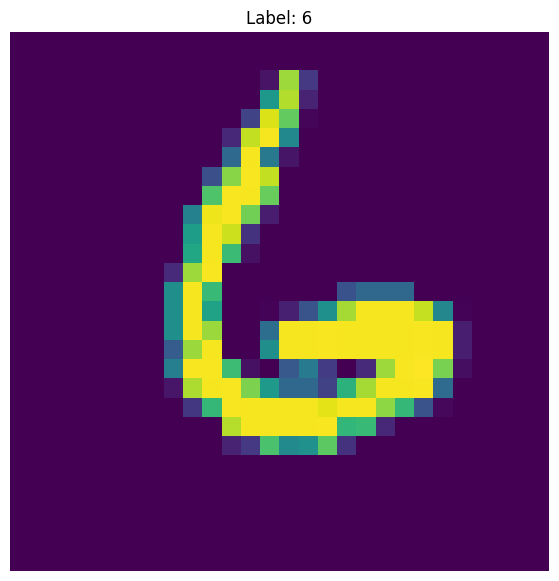

In [ ]:
first_img, first_label = dataloader_img_tensor[0], dataloader_img_label[0]
plt.figure(figsize=(10, 7))
plt.imshow(first_img.squeeze(0))
plt.title(f"Label: {first_label}")
plt.axis("off")

In [ ]:

model.eval()
with torch.inference_mode():
  pred = model(first_img.unsqueeze(dim=0).to(device))

print(f"Output logits: {pred}")
print(f"Output probabilities: {torch.softmax(pred, dim=1)}")
print(f"Output label: {torch.argmax(torch.softmax(pred, dim=1), dim=1)}")
print(f"Actual label: {first_label}")

Output logits: tensor([[ 0.0358, -0.0381,  0.0102,  0.0274,  0.0542,  0.0259,  0.0022, -0.0184,
          0.0217, -0.0093]], device='cuda:0')
Output probabilities: tensor([[0.1025, 0.0952, 0.0999, 0.1016, 0.1044, 0.1015, 0.0991, 0.0971, 0.1010,
         0.0979]], device='cuda:0')
Output label: tensor([4], device='cuda:0')
Actual label: 6


In [ ]:
len(iter(train_dataloader)), len(iter(test_dataloader)), len(train_dataloader)

(1875, 313, 1875)

In [ ]:
img, label = next(iter(train_dataloader))
img.shape, label.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [ ]:
EPOCHS = 1

model.train()
for epoch in range(EPOCHS):
  print(f"___Epoch: {epoch}___")
  batch_loss, batch_accuracy = 0, 0
  eval_batch_loss, eval_batch_accuracy = 0, 0
  for batch, (X_train, y_train) in enumerate(train_dataloader):
    X_train, y_train = X_train.to(device), y_train.to(device)
    y_logits = model(X_train)

    loss = loss_fn(y_logits, y_train)
    batch_loss += loss

    accuracy = (torch.argmax(torch.softmax(y_logits, dim=1), dim=1) == y_train).sum() / len(y_train)
    batch_accuracy += accuracy

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  batch_loss /= len(train_dataloader)
  batch_accuracy /= len(train_dataloader)

  print(f"Batch loss: {batch_loss}")
  print(f"Batch accuracy: {batch_accuracy}")

  model.eval()
  for batch, (X_test, y_test) in enumerate(test_dataloader):
    X_test, y_test = X_test.to(device), y_test.to(device)

    y_eval = model(X_test)

    eval_loss = loss_fn(y_eval, y_test)
    eval_batch_loss += eval_loss

    eval_accuracy = (torch.argmax(torch.softmax(y_eval, dim=1), dim=1) == y_test).sum() / len(y_test)
    eval_batch_accuracy += eval_accuracy

  eval_batch_loss /= len(test_dataloader)
  eval_batch_accuracy /= len(test_dataloader)

  print(f"Batch eval loss: {eval_batch_loss}")
  print(f"Batch eval accuracy: {eval_batch_accuracy}")

___Epoch: 0___
Batch loss: 0.38873210549354553
Batch accuracy: 0.883650004863739
Batch eval loss: 0.11041942983865738
Batch eval accuracy: 0.9675518870353699


Output logits: tensor([[ 1.4342, -2.1569, -1.8566, 11.8065, -6.3931,  7.8097, -4.3741, -4.6540,
          1.0973, -1.4546]], device='cuda:0')
Output probabilities: tensor([[3.0722e-05, 8.4690e-07, 1.1436e-06, 9.8190e-01, 1.2248e-08, 1.8042e-02,
         9.2245e-08, 6.9719e-08, 2.1935e-05, 1.7094e-06]], device='cuda:0')
Output label: tensor([3], device='cuda:0')
Actual label: 3


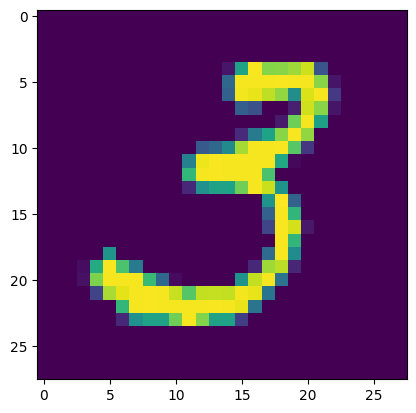

In [ ]:
idx = random.randint(0, 31)
test_img, test_label = dataloader_img_tensor[idx], dataloader_img_label[idx]

model.eval()
with torch.inference_mode():
  pred = model(test_img.unsqueeze(dim=0).to(device))

print(f"Output logits: {pred}")
print(f"Output probabilities: {torch.softmax(pred, dim=1)}")
print(f"Output label: {torch.argmax(torch.softmax(pred, dim=1), dim=1)}")
print(f"Actual label: {test_label}")
plt.imshow(test_img.squeeze(0))